In [1]:
import numpy as np
import polars as pl
import ssm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# based on https://github.com/lindermanlab/ssm/blob/master/doc/notebooks/2-Input-Driven-HMM.md

In [503]:
def firing_by_angle_bin(angles, neural_activity, nbins):
    angles_firing = np.zeros(nbins - 1)
    angles_std = np.zeros(nbins - 1)
    unique_groups, group_counts = np.unique(angles, return_counts=True)
    # mean firing
    group_sums = np.bincount(angles, weights=neural_activity)
    angles_firing[unique_groups] = group_sums[unique_groups] / group_counts
    # std of firing
    group_sums_squared = np.bincount(angles, weights=neural_activity**2)
    mean_squared = angles_firing[unique_groups] ** 2
    variance = (group_sums_squared[unique_groups] / group_counts) - mean_squared
    angles_std[unique_groups] = np.sqrt(variance)
    return angles_firing, angles_std

In [2]:
"""Load synthetic data of hdir cells and real mouse hdir"""
inpt = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\frame_by_synthetichdir_cluster_matrix.npy")
behave = pl.read_csv(r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\full_video_dataframe.csv")
hdir = behave['hdir'].to_numpy()

In [597]:
"""Create states"""
case = "matrix" # "random", "half" 
# case 1: noise added to a random selection of state
if case == "random":
    state = np.random.normal(size = np.shape(inpt)[0])>0
# case 2: noise added to half the recording
if case == "half":
    state = np.zeros(len(hdir))
    state[int(len(hdir)/2):] = 1
if case == "matrix":
    states = [0,1]
    trans_matrix = [[.99,.01],[.2,.8]]
    start_prob = [.65,.35]
    all_state = np.zeros((len(hdir),),dtype = int)
    all_state[0] = np.random.choice(states,p=start_prob)
    for t in range(1,len(hdir)):
        trans = trans_matrix[all_state[t-1]]
        all_state[t] = np.random.choice(states,p=trans)
if case == "length":
    mean = [40*60*1,40*60*5] # (Hz*s*n_min)
    std = [40*10,40*10]
    # create initial segment
    start_prob = [.65,.35]
    s = np.random.choice(states,p=start_prob)
    if s == 1:
        all_state = np.append(s,np.ones(int(np.random.normal(loc = mean[1], scale = std[1]))))
    if s == 0:
        all_state = np.append(s,np.zeros(int(np.random.normal(loc = mean[0], scale = std[0]))))
    # create full sequence
    while len(all_state) < len(hdir):
        if all_state[-1] == 0:
            all_state = np.append(all_state,np.ones(int(np.random.normal(loc = mean[1], scale = std[1]))))
        if all_state[-1] == 1:
            all_state = np.append(all_state,np.zeros(int(np.random.normal(loc = mean[0], scale = std[0]))))
    # ensure appropriate length
    all_state = all_state[:len(hdir)]

In [598]:
"""Apply states"""
state_case = "noise" # "diff_cells", "noise" 

if state_case == "noise":
    noise = np.random.normal(size = np.shape(inpt)[1])
    all_noisyinpt = np. zeros_like(inpt)
    all_noisyinpt[all_state == 0,:] = inpt[all_state == 0,:]
    all_noisyinpt[all_state == 1,:] = inpt[all_state == 1,:]*np.abs(noise) # +(np.ones_like(inpt[state == 1,:])*(noise))
if state_case == "diff_cells":
    all_noisyinpt = np. zeros_like(inpt)
    middle = int(np.shape(inpt)[1]/2)
    all_noisyinpt[all_state == 0,:middle] = inpt[all_state == 0,:middle]
    all_noisyinpt[all_state == 1,middle:] = inpt[all_state == 1,middle:]
if state_case == "scramble":
    all_noisyinpt = np. zeros_like(inpt)
    middle = int(np.shape(inpt)[1]/2)
    # in state 0 listen to the first half of cells
    all_noisyinpt[all_state == 0,:middle] = inpt[all_state == 0,:middle]
    x = inpt[all_state == 0,middle:]
    np.random.shuffle(x)
    all_noisyinpt[all_state == 0,middle:] = x
    # in state 1 listen to the first half of cells
    all_noisyinpt[all_state == 1,middle:] = inpt[all_state == 1,middle:]
    x = inpt[all_state == 1,:middle]
    np.random.shuffle(x)
    all_noisyinpt[all_state == 1,:middle] = x
if state_case == "rotation":
    all_noisyinpt = np. zeros_like(inpt)
    middle = int(np.shape(inpt)[1]/2)
    all_noisyinpt[all_state == 0,:] = inpt[all_state == 0,:]
    all_noisyinpt[all_state == 1,:] = np.roll(inpt[all_state == 1,:],middle, axis = 1)
if state_case == "sign_change":
    all_noisyinpt = np. zeros_like(inpt)
    all_noisyinpt[all_state == 0,:] = inpt[all_state == 0,:]
    all_noisyinpt[all_state == 1,:] = -inpt[all_state == 1,:]

# normalize input - seems to make no difference
# all_noisyinpt = all_noisyinpt/np.amax(all_noisyinpt, axis = 0)

# z-score input
# all_noisyinpt = all_noisyinpt - np.mean(all_noisyinpt, axis = 0)
# all_noisyinpt = all_noisyinpt - np.std(all_noisyinpt, axis = 0)

(array([4385., 1509., 1136., 1490., 1979., 3142., 5043., 3452., 3359.,
        5356.]),
 array([ 0. ,  1.1,  2.2,  3.3,  4.4,  5.5,  6.6,  7.7,  8.8,  9.9, 11. ]),
 <a list of 10 Patch objects>)

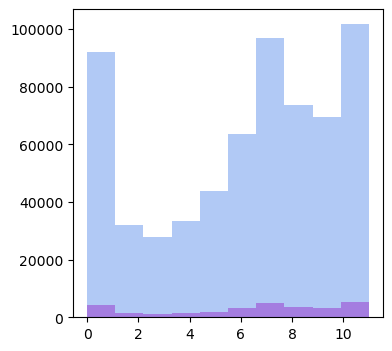

In [650]:
"""Bin hdir"""
number_of_bins = 13
start=-np.pi
stop=np.pi
bin_angles = np.linspace(start, stop, number_of_bins)
bin_angle_center = bin_angles[:-1] + (np.mean(np.diff(bin_angles)) / 2)
all_obs = np.digitize(hdir, bin_angles)-1 # categories have to start at 0

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.hist(all_obs[all_state == 0], alpha = .5, color = ['cornflowerblue'])
axs.hist(all_obs[all_state == 1], alpha = .5, color = ['darkorchid'])

Text(0.5, 1.0, 'firing by angle in the two states')

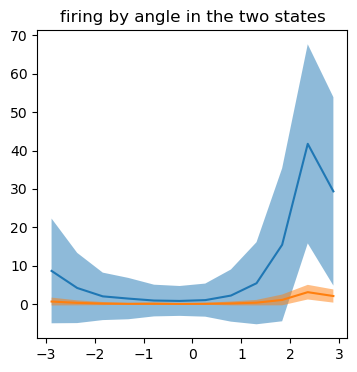

In [654]:
idx = 32
fig,ax = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in np.unique(all_state):
    i = int(i)
    y, error = firing_by_angle_bin(all_obs[all_state == i],all_noisyinpt[all_state == i,idx], number_of_bins)
    ax.fill_between(bin_angle_center, y-error, y+error, alpha=.5, facecolor = colorz[i], linewidth=0)
    ax.plot(bin_angle_center,y, color = colorz[i])
ax.set_title("firing by angle in the two states")

In [655]:
"""Reduce dataset size to speed up the fitting"""
# only use 1/n of the data
denom = 4
length = int(len(all_obs)/denom)
length = 100000
noisyinpt = all_noisyinpt[:length,:]
obs = all_obs[:length]
state = all_state[:len(obs)]

test_input = all_noisyinpt[len(obs):,:]
test_obs = all_obs[len(obs):]
test_state = all_state[len(obs):]

In [656]:
"""Check how different the distributions are across states and keep only very different cells"""
keepers = [8,10,17,25,32]
noisyinpt = noisyinpt[:,keepers]
test_input = test_input[:,keepers]

(array([8.82069537e-02, 2.22771621e-03, 4.24326897e-04, 5.00941475e-05,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]),
 array([  0.,  11.,  22.,  33.,  44.,  55.,  66.,  77.,  88.,  99., 110.]),
 <a list of 10 Patch objects>)

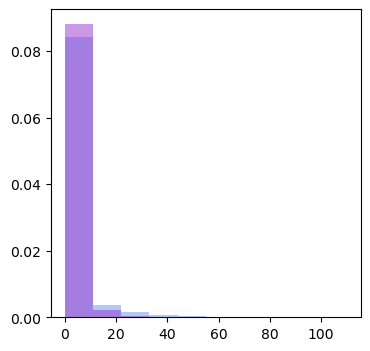

In [640]:
"""Are the distribution of values different enough?"""
idx = 0
fig, axs = plt.subplots(1,1,figsize = (4,4))
biggest = np.amax(np.append(all_noisyinpt[all_state == 0,idx],all_noisyinpt[all_state == 1,idx]))
smally = np.amin(np.append(all_noisyinpt[all_state == 0,idx],all_noisyinpt[all_state == 1,idx]))
axs.hist(all_noisyinpt[all_state == 0,idx], density = True, range = [smally,biggest], alpha = .5, color = ['cornflowerblue'])
axs.hist(all_noisyinpt[all_state == 1,idx], density = True, range = [smally,biggest], alpha = .5, color = ['darkorchid'])

In [657]:
"""Try to fit a GLM-HMM"""
num_states = 2 # by design
obs_dim = 1 # hdir
input_dim = np.shape(noisyinpt)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 100
prior_sigma = 2 # needs a grid search! default = 1000

# initiate the HMM
glm_hmm = ssm.HMM(num_states, 
                  obs_dim, 
                  input_dim, 
                  observations="input_driven_obs", # maybe this allows to pass a categorical observation?!
                  observation_kwargs=dict(C=num_categories, prior_sigma = prior_sigma),
                  transitions="inputdriven") 

# fit the HMM
ll = glm_hmm.fit([np.array([[o] for o in obs])], inputs=[noisyinpt], method="em", num_iters=N_iters, tolerance=10**-4)

  0%|          | 0/100 [00:00<?, ?it/s]

Go over the inputs

In [222]:
# not sure how to parse this - what does it all mean?
exp_states = glm_hmm.expected_states(np.array([[o] for o in obs]), input=noisyinpt)

In [186]:
"""Find permutation"""
# what is this doing? this only works if you know the actual states... very sus
# I think this just ensures that state 0 is state 0 in both pred and true
from ssm.util import find_permutation
glm_hmm.permute(find_permutation(state, glm_hmm.most_likely_states(np.array([[o] for o in obs]), input=noisyinpt)))

In [589]:
"""How well did it guess the transition matrix?"""
if case == "matrix":
    print('predicted transitions matrix are: ' + str([list(glm_hmm.transitions.transition_matrix[0]),list(glm_hmm.transitions.transition_matrix[1])]) + '\n input transition matrix are: ' + str(trans_matrix))
else:
    print('predicted transitions matrix are: ' + str([list(glm_hmm.transitions.transition_matrix[0]),list(glm_hmm.transitions.transition_matrix[1])]))

predicted transitions matrix are: [[0.9854691433200512, 0.014530856679948728], [0.019349282284129944, 0.98065071771587]]


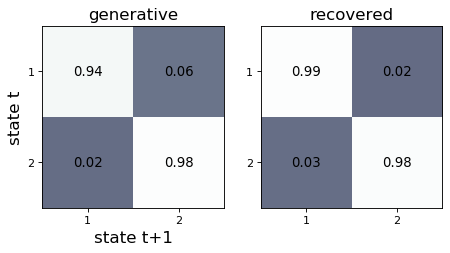

In [593]:
"""Compare transition matrix real and predicted"""
fig = plt.figure(figsize=(5, 2.5), dpi=80, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
trans_matrix = np.array(trans_matrix)
plt.imshow(trans_matrix, vmin=-0.8, vmax=1, cmap='bone')
for i in range(trans_matrix.shape[0]):
    for j in range(trans_matrix.shape[1]):
        text = plt.text(j, i, str(np.around(trans_matrix[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, num_states - 0.5)
plt.xticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.ylim(num_states - 0.5, -0.5)
plt.ylabel("state t", fontsize = 15)
plt.xlabel("state t+1", fontsize = 15)
plt.title("generative", fontsize = 15)


plt.subplot(1, 2, 2)
recovered_trans_mat = np.exp(glm_hmm.transitions.log_Ps)
plt.imshow(recovered_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(recovered_trans_mat.shape[0]):
    for j in range(recovered_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(recovered_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, num_states - 0.5)
plt.xticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.ylim(num_states - 0.5, -0.5)
plt.title("recovered", fontsize = 15)
plt.subplots_adjust(0, 0, 1, 1)

Text(0.5, 1.0, '% time in state 0, real: 0.95 , predicted: 0.72\n% time in state 1, real: 0.05 , predicted: 0.28')

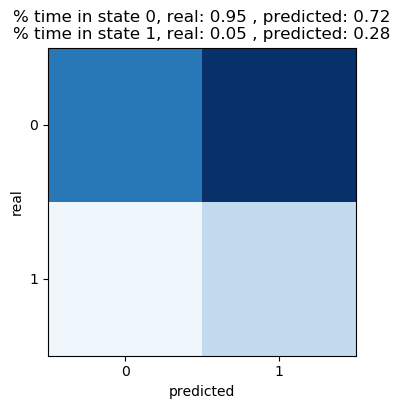

In [642]:
"""How well did it guess the state at each time?"""
state_pred = glm_hmm.most_likely_states(np.array([[o] for o in obs]), input=noisyinpt)

conf = confusion_matrix(state, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(state == 0)/len(state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(state == 1)/len(state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))

Text(0, 0.5, 'Fraction of state bouts')

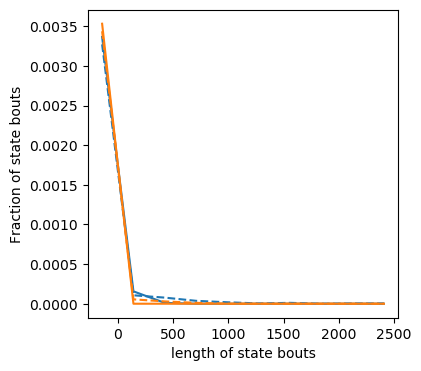

In [658]:
"""How long does each state bout last?"""

real_time = []
for i in np.arange(num_states):
    st = (state == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    real_time.append(np.abs(start - end))

pred_time = []
for i in np.arange(num_states):
    st = (state_pred == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    pred_time.append(np.abs(start - end))

longest = np.amax(np.append(np.concatenate(pred_time), np.concatenate(real_time)))
shortest = np.amin(np.append(np.concatenate(pred_time), np.concatenate(real_time)))

fig, axs = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in np.arange(num_states):
    # real
    h, b = np.histogram(real_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '-', color = colorz[i])
    # pred
    h, b = np.histogram(pred_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '--', color = colorz[i])

axs.set_xlabel('length of state bouts')
axs.set_ylabel('Fraction of state bouts')

Text(0.5, 0, 'binned angles')

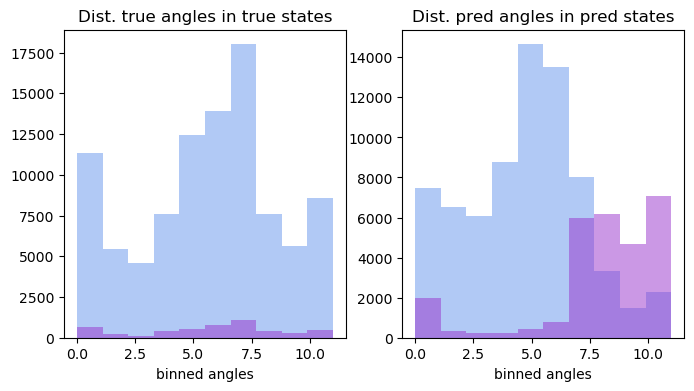

In [667]:
"""Distribution of angles in the two states"""
pred_latents, pred_angles = glm_hmm.sample(len(obs), input=noisyinpt)

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].hist(obs[state == 0], alpha = .5, color = ['cornflowerblue'])
axs[0].hist(obs[state == 1], alpha = .5, color = ['darkorchid'])
axs[0].set_title('Dist. true angles in true states')
axs[0].set_xlabel('binned angles')

axs[1].hist(pred_angles[pred_latents == 0], alpha = .5, color = ['cornflowerblue'])
axs[1].hist(pred_angles[pred_latents == 1], alpha = .5, color = ['darkorchid'])
axs[1].set_title('Dist. pred angles in pred states')
axs[1].set_xlabel('binned angles')


Text(0.5, 1.0, 'pred state 1')

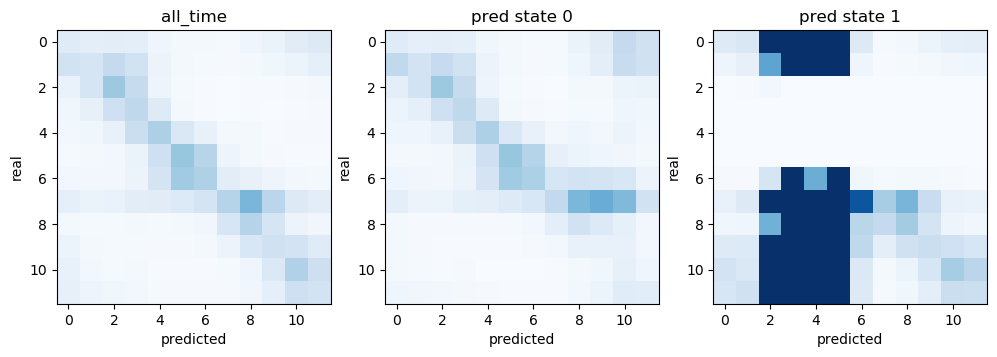

In [668]:
"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(obs, pred_angles)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,3,figsize = (12,4))
axs[0].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[0].set_ylabel("real")
axs[0].set_xlabel("predicted")
axs[0].set_title("all_time")

conf = confusion_matrix(obs[pred_latents == 0], pred_angles[pred_latents == 0])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[1].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[1].set_ylabel("real")
axs[1].set_xlabel("predicted")
axs[1].set_title("pred state 0")

conf = confusion_matrix(obs[pred_latents == 1], pred_angles[pred_latents == 1])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[2].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[2].set_ylabel("real")
axs[2].set_xlabel("predicted")
axs[2].set_title("pred state 1")

Text(0.5, 1.0, 'weights per category in the two states')

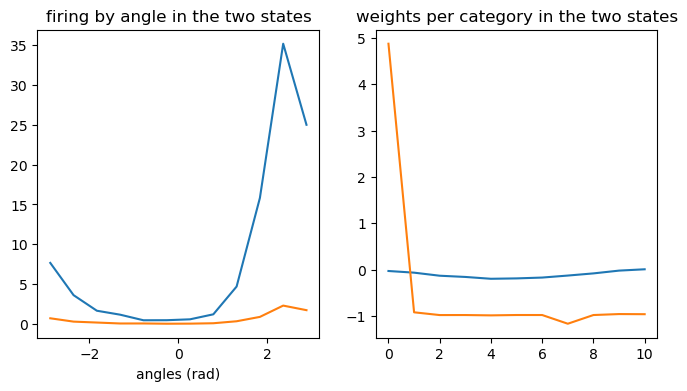

In [665]:
idx = 4
fig,ax = plt.subplots(1,2,figsize = (8,4))
y, _ = firing_by_angle_bin(obs[state == 0],noisyinpt[state == 0,idx], number_of_bins)
ax[0].plot(bin_angle_center,y)
y, _ = firing_by_angle_bin(obs[state == 1],noisyinpt[state == 1,idx], number_of_bins)
ax[0].plot(bin_angle_center,y)
ax[0].set_title("firing by angle in the two states")
ax[0].set_xlabel('angles (rad)')

ax[1].plot(glm_hmm.observations.Wk[0,:,idx])
ax[1].plot(glm_hmm.observations.Wk[1,:,idx])
ax[1].set_title("weights per category in the two states")

Cross validation

In [ ]:
"""Find permutation"""
# what is this doing?
from ssm.util import find_permutation
glm_hmm.permute(find_permutation(test_state, glm_hmm.most_likely_states(np.array([[o] for o in test_obs]), input=test_input)))

Text(0.5, 1.0, '% time in state 0, real: 0.25 , predicted: 0.49\n% time in state 1, real: 0.75 , predicted: 0.51')

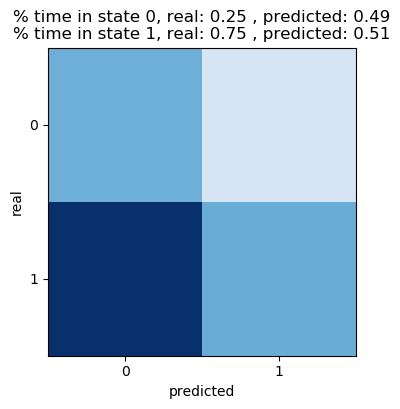

In [237]:
"""How well did it guess the states?"""
state_pred_test = glm_hmm.most_likely_states(np.array([[o] for o in test_obs]), input=test_input)

conf = confusion_matrix(test_state, state_pred_test)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(test_state == 0)/len(test_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred_test == 0)/len(state_pred_test)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(test_state == 1)/len(test_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred_test == 1)/len(state_pred_test)))

Text(0.5, 1.0, 'Dist. pred angles in pred states')

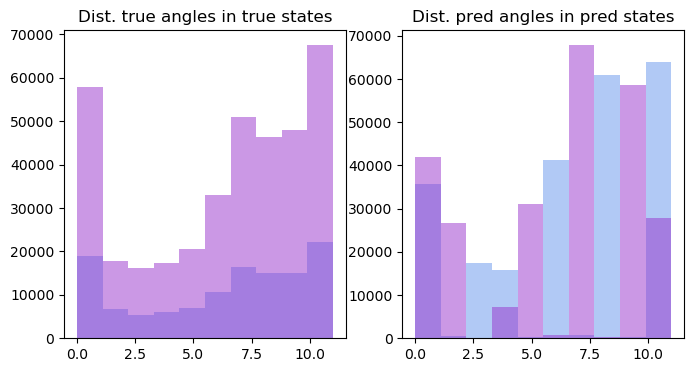

In [238]:
"""Distribution of angles in the two states"""
pred_latents_test, pred_angles_test = glm_hmm.sample(len(test_obs), input=test_input)

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].hist(test_obs[test_state == 0], alpha = .5, color = ['cornflowerblue'])
axs[0].hist(test_obs[test_state == 1], alpha = .5, color = ['darkorchid'])
axs[0].set_title('Dist. true angles in true states')
axs[0].set_xlabel('binned angles')

axs[1].hist(pred_angles_test[pred_latents_test == 0], alpha = .5, color = ['cornflowerblue'])
axs[1].hist(pred_angles_test[pred_latents_test == 1], alpha = .5, color = ['darkorchid'])
axs[1].set_title('Dist. pred angles in pred states')
axs[1].set_xlabel('binned angles')

Text(0.5, 1.0, 'pred state 1')

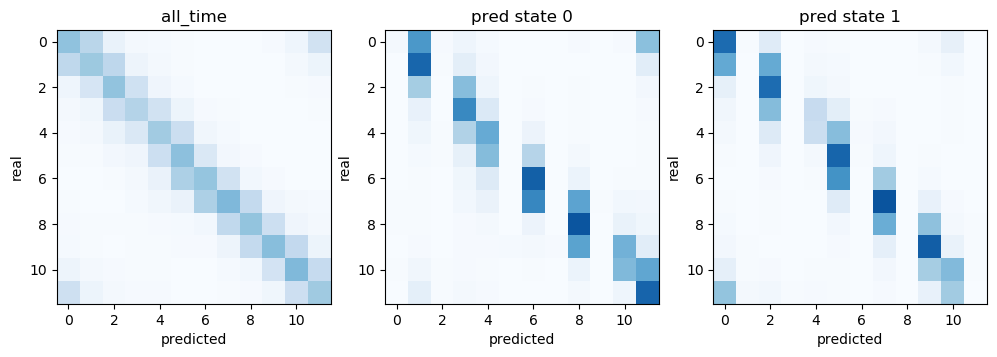

In [239]:
"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(test_obs, pred_angles_test)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,3,figsize = (12,4))
axs[0].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[0].set_ylabel("real")
axs[0].set_xlabel("predicted")
axs[0].set_title("all_time")

conf = confusion_matrix(test_obs[pred_latents_test == 0], pred_angles_test[pred_latents_test == 0])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[1].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[1].set_ylabel("real")
axs[1].set_xlabel("predicted")
axs[1].set_title("pred state 0")

conf = confusion_matrix(test_obs[pred_latents_test == 1], pred_angles_test[pred_latents_test == 1])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[2].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[2].set_ylabel("real")
axs[2].set_xlabel("predicted")
axs[2].set_title("pred state 1")